In [1]:
# Hex grid — three densities (regular / extra / super).
# Pointy-top hexagons tessellating the usable rectangle. Per-density
# LINE_WIDTH matches graph (10/6/4). Vertex offsets are derived from the
# centroid of three mutually adjacent hex centers so neighbors share
# vertices algebraically:
#   top:    (0,        -2P_y/3)
#   ur:     (+P_x/2,   -P_y/3)
#   lr:     (+P_x/2,   +P_y/3)
#   bot:    (0,        +2P_y/3)
#   ll:     (-P_x/2,   +P_y/3)
#   ul:     (-P_x/2,   -P_y/3)
#
# MARGIN MATH (hex is DIFFERENT from dot/line modes!).
# A hex extends outward from its center by P_x/2 horizontally and
# 2*P_y/3 vertically, plus LW/2 for line thickness. If you placed hex
# centers on the dot lattice (first center at edge_margin), the leftmost
# hex would overflow the page by P_x/2 + LW/2 pixels.
# Instead, we anchor the leftmost OUTLINE PIXEL to M_x and the topmost
# outline pixel to HEADER_HEIGHT + M_y. Solving for integer N_x, N_y:
#   N_x = LATTICE_W // P_x           (one fewer than dot lattice)
#   M_x = edge_margin(LW)            (exact match with graph/dotted)
#   N_y = LATTICE_H // P_y
#   M_y = (USABLE_H - (N_y-1)*P_y - 4*P_y/3 - LW) / 2
#
# VERTICAL MARGIN (M_y) DIFFERS FROM HORIZONTAL (M_x). The hex aspect
# ratio (~1.155 tall) doesn't match the usable rect aspect (~0.77), so
# the residual vertical whitespace comes out smaller than 120 px. Per
# density we accept the best-fit M_y (each still exact top=bottom):
#   regular  M_x=120  M_y=85
#   extra    M_x=122  M_y≈101.17 (sub-pixel due to P_y/3 fractional)
#   super    M_x=123  M_y≈106.33 (sub-pixel)
# See SPEC.md for the full derivation.
#
# CONSTRAINT CONFLICTS already documented in isometric / common.py:
#   - True 60° requires irrational P_y/P_x; we pick best integer.
#   - P_y/3 non-integer for extra/super — PIL handles float vertices;
#     adjacent hexes share the same float, so tessellation is seamless.
#
# Output: ../output/hex/{hex,extra-hex,super-hex}.png
from PIL import Image, ImageDraw
from IPython.display import display
from common import (
    blank_page, draw_header, FG_COLOR, edge_margin,
    LATTICE_W, LATTICE_H, HEIGHT, HEADER_HEIGHT,
    output_path, variant_name,
)

MODE = "hex"
USABLE_H = HEIGHT - HEADER_HEIGHT   # 10750

HEX = {
    "regular": (250, 210, 10),
    "extra":   (150, 125,  6),
    "super":   (110, 100,  4),
}

In [2]:
def hex_vertices(cx, cy, P_x, P_y):
    """Six pointy-top hex vertices in CCW order, plus a repeat of the
    first vertex to close the loop for PIL's joint='curve' line."""
    hx = P_x / 2
    hy = P_y / 3
    return [
        (cx,        cy - 2 * hy),
        (cx + hx,   cy - hy),
        (cx + hx,   cy + hy),
        (cx,        cy + 2 * hy),
        (cx - hx,   cy + hy),
        (cx - hx,   cy - hy),
        (cx,        cy - 2 * hy),
    ]


def render_hex(P_x, P_y, line_width):
    assert P_x % 2 == 0
    assert LATTICE_W % P_x == 0 and LATTICE_H % P_y == 0
    # Horizontal: hex outlines anchor at M_x = edge_margin(LW).
    n_x_even = LATTICE_W // P_x             # NOT +1; hex extends past center
    n_x_odd  = n_x_even - 1
    m_x      = edge_margin(line_width)
    first_cx = m_x + P_x / 2 + line_width / 2
    # Vertical: best-fit integer N_y; M_y is residual whitespace / 2.
    n_y      = LATTICE_H // P_y
    span_y   = (n_y - 1) * P_y + 4 * P_y / 3 + line_width
    m_y      = (USABLE_H - span_y) / 2
    first_cy = HEADER_HEIGHT + m_y + 2 * P_y / 3 + line_width / 2
    # Render.
    img = blank_page()
    draw = ImageDraw.Draw(img)
    count = 0
    for j in range(n_y):
        cy = first_cy + j * P_y
        if j % 2 == 0:
            xs = [first_cx + i * P_x for i in range(n_x_even)]
        else:
            xs = [first_cx + P_x / 2 + i * P_x for i in range(n_x_odd)]
        for cx in xs:
            verts = hex_vertices(cx, cy, P_x, P_y)
            draw.line(verts, fill=FG_COLOR, width=line_width, joint="curve")
            count += 1
    draw_header(img)
    return img, n_x_even, n_y, count, m_x, m_y

regular  P_x=250 P_y=210 lw=10  33×50= 1625 hexes  M_x=120  M_y=85.00  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/hex/hex.png


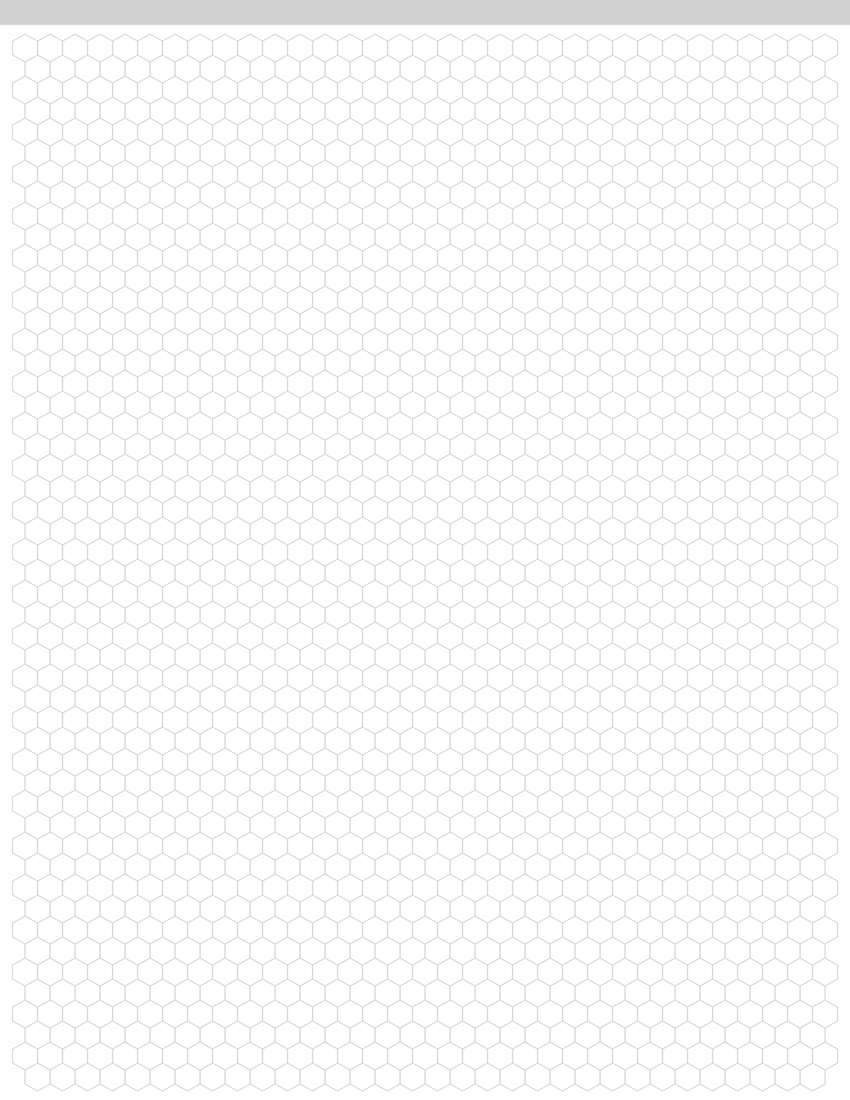

extra    P_x=150 P_y=125 lw= 6  55×84= 4578 hexes  M_x=122  M_y=101.17  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/hex/extra-hex.png


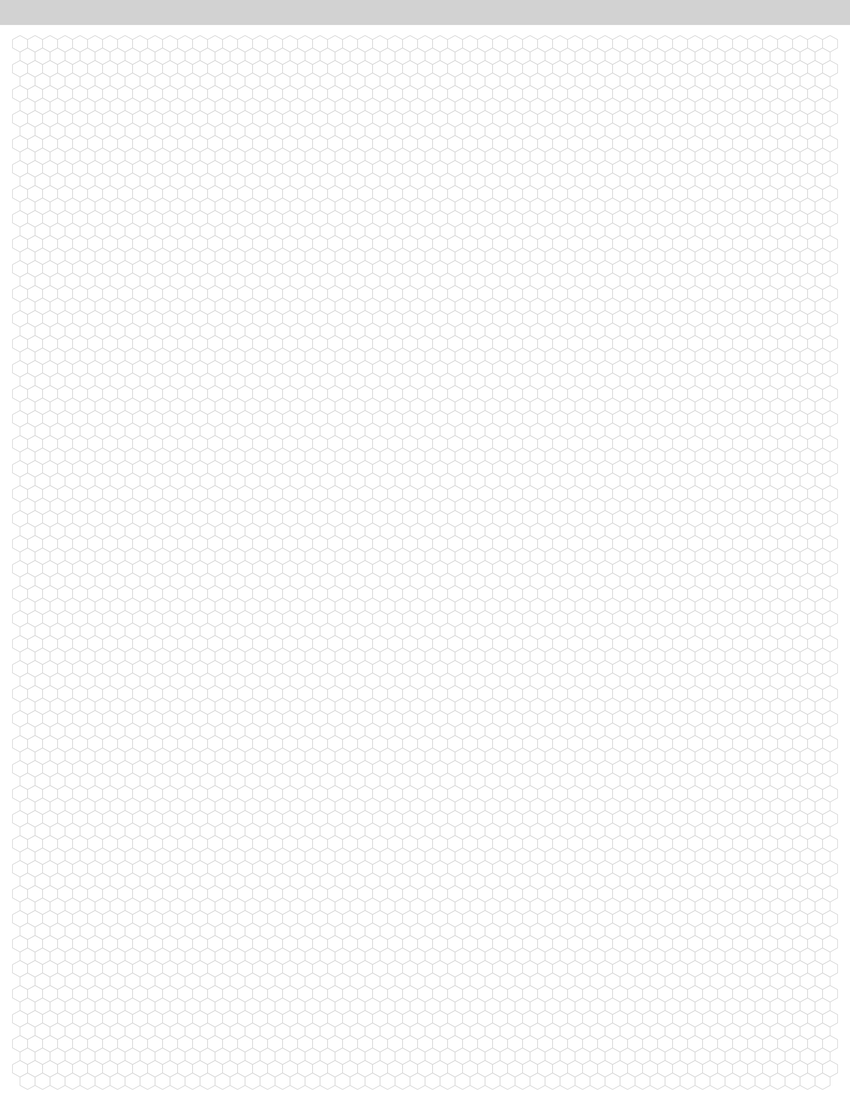

super    P_x=110 P_y=100 lw= 4  75×105= 7823 hexes  M_x=123  M_y=106.33  →  /Users/andrewzhou/Desktop/projects/personal/paper-generation/output/hex/super-hex.png


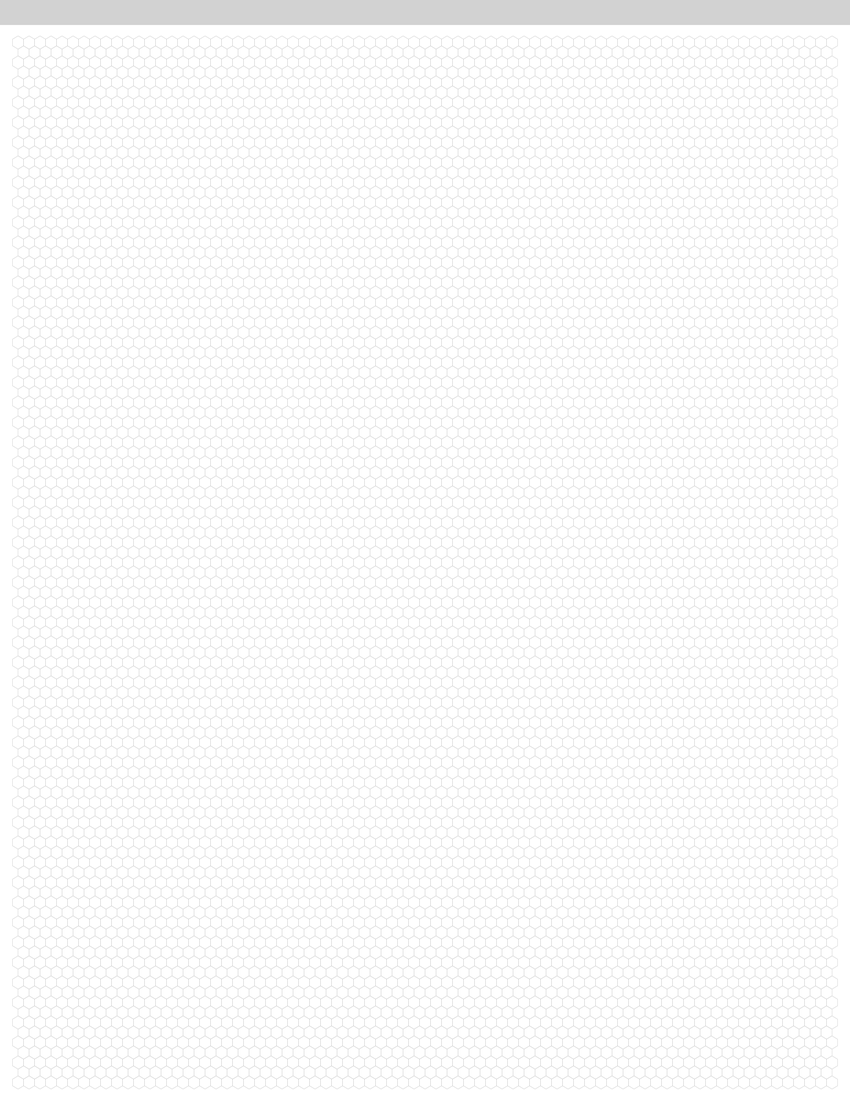

In [3]:
for density, (P_x, P_y, lw) in HEX.items():
    img, nx, ny, count, mx, my = render_hex(P_x, P_y, lw)
    path = output_path(MODE, variant_name(MODE, density))
    img.save(path, "PNG")
    print(
        f"{density:8s} P_x={P_x:3d} P_y={P_y:3d} lw={lw:2d}  "
        f"{nx}×{ny}={count:5d} hexes  M_x={mx}  M_y={my:.2f}  →  {path}"
    )
    display(img.resize((850, 1100), Image.LANCZOS))